<a href="https://colab.research.google.com/github/AleixoCodes/Machine-Learning-com-dados-do-Spotify/blob/main/Analise_dos_dados_com_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisando dados do Spotify e prevendo músicas populares com Machine Learning**

## **Importando Dados**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import kagglehub

path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


In [9]:
dadosMusicais = pd.read_csv("/kaggle/input/-spotify-tracks-dataset/dataset.csv")
dadosMusicais

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


### Traduzindo dataframe

In [10]:
dadosMusicais.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

listaEN = ['track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre']

listaPT = ['track_id', 'artistas', 'nome_do_album', 'nome_da_musica',
       'popularidade', 'duracao_ms', 'explicito', 'dancabilidade', 'energia',
       'chave', 'volume', 'modo', 'falada', 'acustica',
       'instrumental', 'ao_vivo', 'positividade', 'tempo', 'tempo_de_assinatura',
       'genero_musical']

dadosMusicais.columns = listaPT
dadosMusicais.head()

,track_id,artistas,nome_do_album,nome_da_musica,popularidade,duracao_ms,explicito,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,genero_musical
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## **Analisando estatísticas dos dados**

In [11]:
dadosMusicais.shape

(114000, 20)

In [12]:
dadosMusicais.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   track_id             114000 non-null  object 
 1   artistas             113999 non-null  object 
 2   nome_do_album        113999 non-null  object 
 3   nome_da_musica       113999 non-null  object 
 4   popularidade         114000 non-null  int64  
 5   duracao_ms           114000 non-null  int64  
 6   explicito            114000 non-null  bool   
 7   dancabilidade        114000 non-null  float64
 8   energia              114000 non-null  float64
 9   chave                114000 non-null  int64  
 10  volume               114000 non-null  float64
 11  modo                 114000 non-null  int64  
 12  falada               114000 non-null  float64
 13  acustica             114000 non-null  float64
 14  instrumental         114000 non-null  float64
 15  ao_vivo          

In [13]:
dadosMusicais.describe()

,popularidade,duracao_ms,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [14]:
# Analisando valores nulos
dadosMusicais.isnull().sum()

,0
track_id,0
artistas,1
nome_do_album,1
nome_da_musica,1
popularidade,0
duracao_ms,0
explicito,0
dancabilidade,0
energia,0
chave,0


Ranking artistas populares

In [15]:
ranking_popularidade = dadosMusicais[['artistas','popularidade']]
ranking_popularidade = ranking_popularidade.groupby('artistas').mean().sort_values(by='popularidade', ascending=False).reset_index()
ranking_popularidade

,artistas,popularidade
0,Sam Smith;Kim Petras,100.0
1,Bizarrap;Quevedo,99.0
2,Manuel Turizo,98.0
3,Bad Bunny;Chencho Corleone,97.0
4,Bad Bunny;Bomba Estéreo,94.5
...,...,...
31432,Niccolò Paganini;Salvatore Accardo;London Phil...,0.0
31433,Niccolò Paganini;Kanako Yanagida;Kentaro Ifuku,0.0
31434,Whethan;Oliver Tree,0.0
31435,BANKS,0.0


Ranking músicas mais duradouras

In [16]:
long_music = dadosMusicais[['nome_da_musica','duracao_ms']]
long_music = long_music.groupby('nome_da_musica').mean().sort_values(by='duracao_ms', ascending=False).reset_index()
long_music

,nome_da_musica,duracao_ms
0,Unity (Voyage Mix) Pt. 1,5237295.0
1,Crossing Wires 002 - Continuous DJ Mix,4789026.0
2,The Lab 03 - Continuous DJ Mix Part 1,4730302.0
3,Amnesia Ibiza Underground 10 DJ Mix,4563897.0
4,House of Om - Mark Farina - Continuous Mix,4447520.0
...,...,...
73603,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",17826.0
73604,"Andante in C Major, K. 1a",17453.0
73605,Screams for a Finale! (feat. Leila's Opera Class),15800.0
73606,V-4,13386.0


Ranking músicas mais "dançáveis"

In [17]:
danceability_music = dadosMusicais[['nome_da_musica','dancabilidade']]
danceability_music = danceability_music.groupby('nome_da_musica').mean().sort_values(by='dancabilidade', ascending=False).reset_index()
danceability_music

,nome_da_musica,dancabilidade
0,Sol Clap,0.985
1,Medicaid Baby,0.984
2,Daily Routines,0.982
3,"Featuring Mixx Master Lee, Red Rum & J. Smoov ...",0.981
4,Dancing in My Room,0.980
...,...,...
73603,Spray Paint,0.000
73604,Ferme Les Yeux,0.000
73605,Vacum Cleaner,0.000
73606,Ionian,0.000


## **Adaptando os dados para algoritmo**

In [18]:
dadosMusicais.drop_duplicates()
dadosMusicais.dropna()
dadosMusicais['popular_binario'] = dadosMusicais['popularidade'].apply(lambda x: 1 if x >= 70 else 0)
dadosMusicais

,track_id,artistas,nome_do_album,nome_da_musica,popularidade,duracao_ms,explicito,dancabilidade,energia,chave,...,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,genero_musical,popular_binario
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,1
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,0
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,0
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,0
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,0


Filtrando DF para dados quantitativos

In [19]:
dados_quantitativos = dadosMusicais
drop_qualitativos = []
for col in dados_quantitativos.columns:
  if dados_quantitativos[col].dtype == 'object':
    drop_qualitativos.append(col)
dados_quantitativos = dados_quantitativos.drop(columns=drop_qualitativos, errors='ignore')

dados_quantitativos = dados_quantitativos.drop(columns=['explicito'])
dados_quantitativos

,popularidade,duracao_ms,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,popular_binario
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,1
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,0
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,0
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,1
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,0
113996,22,385000,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,0
113997,22,271466,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,0
113998,41,283893,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,0


Normalizando dados

In [20]:
dadosNormalizados = dados_quantitativos.copy()
dadosNormalizados = (dadosNormalizados - dadosNormalizados.min()) / (dadosNormalizados.max() - dadosNormalizados.min())
dadosNormalizados

,popularidade,duracao_ms,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,popular_binario
0,0.73,0.044043,0.686294,0.4610,0.090909,0.791392,0.0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,0.8,1.0
1,0.55,0.028566,0.426396,0.1660,0.090909,0.597377,1.0,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,0.8,0.0
2,0.57,0.040255,0.444670,0.3590,0.000000,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.8,0.0
3,0.71,0.038557,0.270051,0.0596,0.000000,0.573701,1.0,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,0.6,1.0
4,0.82,0.037969,0.627411,0.4430,0.181818,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.8,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,0.21,0.073511,0.174619,0.2350,0.454545,0.612952,1.0,0.043731,0.642570,0.928000,0.0863,0.034070,0.517705,1.0,0.0
113996,0.22,0.073511,0.176650,0.1170,0.000000,0.577345,0.0,0.041554,0.997992,0.976000,0.1050,0.035176,0.350242,0.8,0.0
113997,0.22,0.051833,0.638579,0.3290,0.000000,0.714648,0.0,0.043523,0.870482,0.000000,0.0839,0.746734,0.543933,0.8,0.0
113998,0.41,0.054206,0.595939,0.5060,0.636364,0.714759,1.0,0.030777,0.382530,0.000000,0.2700,0.415075,0.558651,0.8,0.0


### **Divisão do data frame**

Para divisão do dataset, separou-se em treino e teste, sendo que o teste será dividido com 20% de todo o conjunto e será usado somente após o modelo ser escolhido e ajustado.

Já os dados de treino, serão separados em treino e validação. Sendo os dados de validação usados para comparação de diferentes modelos e hiperparâmetros.

- Dados de treinamento: usado para treinar o modelo.

- Dados de validação: usado para comparação de diferentes modelos e hiperparâmetros.

- Dados de teste: usado para comprovar que aquele modelo realmente funciona. São dados ignorados no treinamento e no processo de escolha de hiperparâmetros.

In [21]:
from sklearn.model_selection import train_test_split

# Dividindo dataframe
dadosTreino, dadosTeste = train_test_split(dadosNormalizados, test_size=0.2, random_state=42, shuffle=True)

pop_norm_train = dadosTreino.popular_binario.value_counts(normalize=True)
pop_norm_test = dadosTeste.popular_binario.value_counts(normalize=True)

print(f'População de treino: {pop_norm_train}\n')
print(f'População de teste: {pop_norm_test}')

População de treino: popular_binario
0.0    0.951524
1.0    0.048476
Name: proportion, dtype: float64

População de teste: popular_binario
0.0    0.953904
1.0    0.046096
Name: proportion, dtype: float64


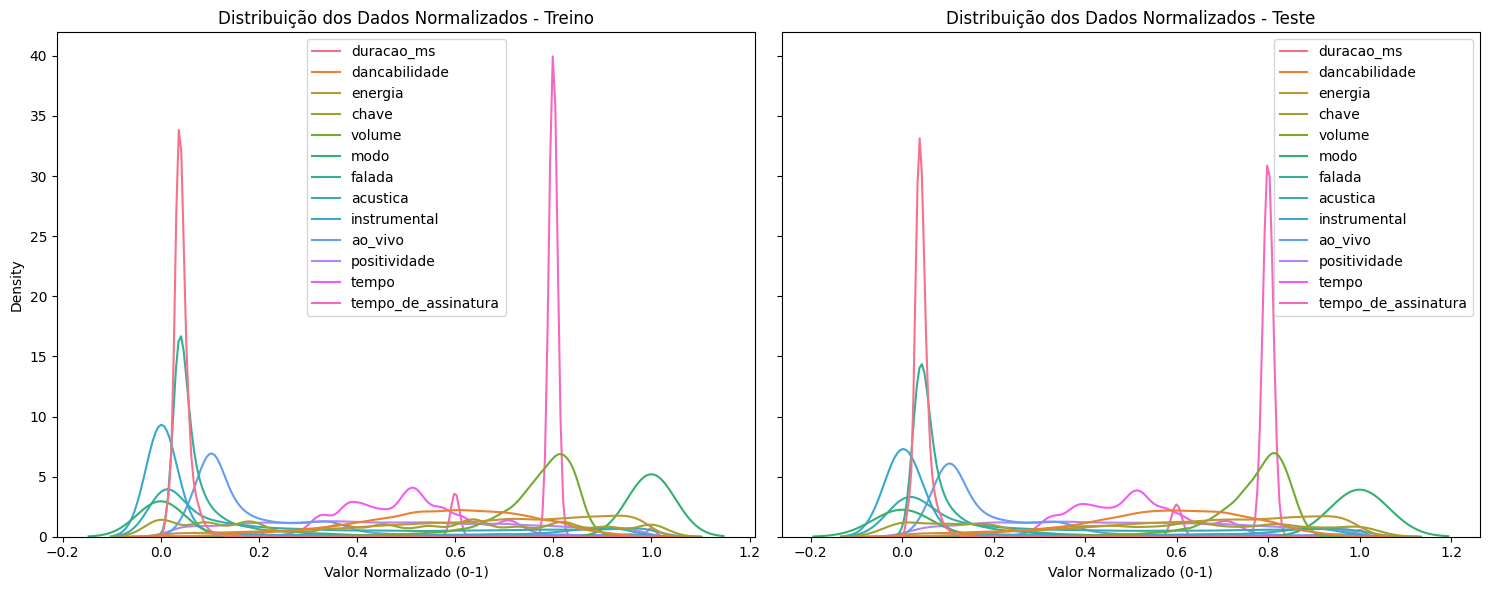

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a figura para dois subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot para os dados de treino
sns.kdeplot(data=dadosTreino.drop(columns=['popularidade', 'popular_binario']), ax=axes[0], common_norm=False)
axes[0].set_title('Distribuição dos Dados Normalizados - Treino')
axes[0].set_xlabel('Valor Normalizado (0-1)')

# Plot para os dados de teste
sns.kdeplot(data=dadosTeste.drop(columns=['popularidade', 'popular_binario']), ax=axes[1], common_norm=False)
axes[1].set_title('Distribuição dos Dados Normalizados - Teste')
axes[1].set_xlabel('Valor Normalizado (0-1)')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import StratifiedKFold

# Dividindo em X (características) e y (alvo)
X = dadosTreino.drop(columns=['popularidade', 'popular_binario'], axis=1)
y = dadosTreino.popular_binario

# Inicializando o StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Looping para separar dados de treino e validação
# Nota: O loop percorre os folds, mas as variáveis finais conterão apenas o último fold executado
for train_index, val_index in skf.split(X, y):
    X_treino, X_val = X.iloc[train_index], X.iloc[val_index]
    y_treino, y_val = y.iloc[train_index], y.iloc[val_index]

# Analisando proporções da classe 1 (músicas populares)
# Corrigido: acessando 'y' em vez de 'X' para verificar a classe
print(f'Dimensão: {X_treino.shape, X_val.shape, y_treino.shape, y_val.shape}')
print(f'Proporção total dos dados de treino na classe 1: {round(y.mean(), 4)}')
print(f'Proporção do fold de treino na classe 1: {round(y_treino.mean(), 4)}')
print(f'Proporção do fold de validação na classe 1: {round(y_val.mean(), 4)}')

Dimensão: ((72960, 13), (18240, 13), (72960,), (18240,))
Proporção total dos dados de treino na classe 1: 0.0485
Proporção do fold de treino na classe 1: 0.0485
Proporção do fold de validação na classe 1: 0.0485


## **Atribuindo baseline do modelo**

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instanciando o modelo
RegLog = LogisticRegression(random_state=42)

# Treinando o modelo
RegLog.fit(X_treino, y_treino)

# Fazendo previsões nos dados de validação
y_pred_val = RegLog.predict(X_val)

# Avaliando o modelo baseline
print('Acurácia na Validação:', accuracy_score(y_val, y_pred_val))
print('\nRelatório de Classificação:')
print(classification_report(y_val, y_pred_val))

Acurácia na Validação: 0.9514802631578947

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98     17355
         1.0       0.00      0.00      0.00       885

    accuracy                           0.95     18240
   macro avg       0.48      0.50      0.49     18240
weighted avg       0.91      0.95      0.93     18240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


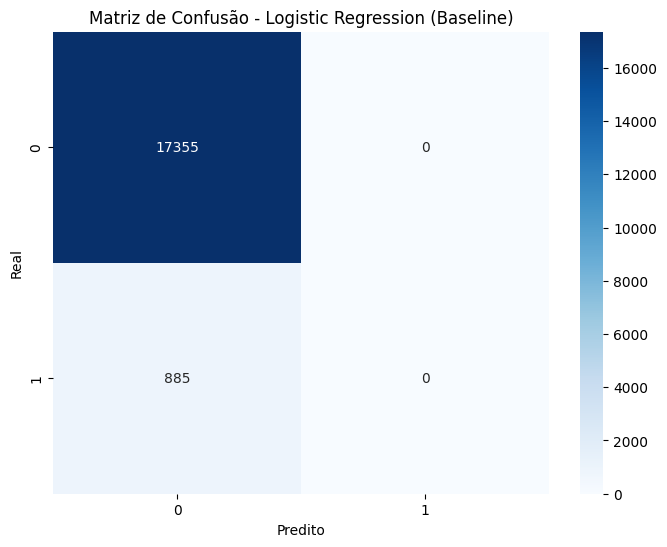

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de Confusão para visualizar o desempenho do baseline
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Logistic Regression (Baseline)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()